In [51]:
import numpy as np
import math
from matplotlib import pyplot as plt
import sys
np.set_printoptions(threshold=sys.maxsize)

from src.initial_data import initial_data
from src.integrators import solve_ODE
from src.error import wass_2_approx

# Configuration


In [52]:
r_c = .25
tau = .1

h = .001
moll_eps = 4 * h**(.99)
my_eps = 4 * h**(.99) 
xi_eps = 4 * h**(.99)

t_max = .05
t_step = 10**(-4)

# Parameters for random blob methods
alg = 1
num_batches = 1
ratio = 1

# Function definitions


In [53]:
# Distribution of our initial data
def rho_0(x):
  return exact(0, x)

def grad_V(x):
  return 0

def smooth_step(t):
    t = np.clip(t, 0.0, 1.0)
    return 6 * t**5 - 15 * t**4 + 10 * t**3
def smooth_step_deriv(t):
    t = np.clip(t, 0.0, 1.0)
    return 30 * t**4 - 60 * t**3 + 30 * t**2

def f_double_prime_epsilon(x):
    dy = np.zeros_like(x, dtype=float)
    
    x0 = r_c - my_eps
    x1 = r_c + my_eps
    dt_dx = 1.0 / (2.0 * my_eps)
    
    # Masks
    mask_left  = x <= x0
    mask_mid   = (x > x0) & (x < x1)
    mask_right = x >= x1
    
    # 1. Left region: f(x) = 0, f'(x) = 0
    dy[mask_left] = 0.0
    
    # 2. Right region: f(x) = 1 + ln(x/r_c), f'(x) = 1/x
    dy[mask_right] = 1.0 / x[mask_right]
    
    # 3. Middle transition region
    x_mid = x[mask_mid]
    t = (x_mid - x0) * dt_dx
    
    S_t = smooth_step(t)
    S_prime_t = smooth_step_deriv(t)
    g_x = 1.0 + np.log(x_mid / r_c)
    g_prime_x = 1.0 / x_mid
        
    # Product rule: d(S*g)/dx = dS/dx * g + S * dg/dx
    # Chain rule for dS/dx = S'(t) * dt/dx
    dy[mask_mid] = (S_prime_t * dt_dx) * g_x + S_t * g_prime_x
    return dy

# Exact solution
def exact(t, x):
  s = t + tau

  def L2(s):
      if r_c <= 1 / np.sqrt(4 * np.pi * s):
        return 2 * np.sqrt(- s * np.log(r_c * np.sqrt(4 * np.pi * s)))
      else:
        return 0
  def R1(s):
    return - L2(s)
  def L1(s):
    if r_c <= 1 / np.sqrt(4 * np.pi * s):
      m = (math.erf(L2(s) / (2 * np.sqrt(s))) - math.erf(R1(s) / (2 * np.sqrt(s)))) / 2
      return R1(s) + (m - 1) / (2 * r_c)
    else:
      return -1/(2 * r_c)   
  def R2(s):
    return - L1(s)
   
  leftCharFunction = r_c * (x >= L1(s)) * (x <= R1(s))
  rightCharFunction = r_c * (x >= L2(s)) * (x <= R2(s))
  middleFunction = (x > R1(s)) * (x < L2(s)) * (1 / np.sqrt(4 * np.pi * s)) * np.exp(- x**2 / (4 * s))
  return leftCharFunction + rightCharFunction + middleFunction


# Plot


In [54]:
def xi(x):
    denom = (2 * np.pi * (xi_eps**2))**(1 / 2)
    arg = - (x**2) / (2 * (xi_eps**2))
    return np.exp(arg) / denom

def smooth(input, m_vals, part_sol):
    return np.dot(xi(input[:, None] - part_sol), m_vals)

def plot_inset(particle_sol, m_vals, num_steps = 5):
    plt.rcParams.update({'font.size': 20})
    plt.rcParams['text.usetex'] = True
    plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'

    fig, ax = plt.subplots()
    x_vals = np.arange(- 2, 2, .01)
    colors = plt.cm.viridis(np.linspace(0, 1, num_steps))
    jump_size = int(particle_sol.shape[0] / (num_steps - 1))

    # Plot particles BEFORE final time
    for i in range(num_steps - 1):
        y_vals = smooth(x_vals, m_vals, particle_sol[i * jump_size])
        lab = rf'$t = {round(t_max * (jump_size / particle_sol.shape[0]) * i, 4)}$'
        if i == 3:
            lab = rf'$t = 0.0375$'
        ax.plot(x_vals, y_vals, '--', linewidth=5, label=lab, color=colors[i])

    # Plot final step
    y_vals = smooth(x_vals, m_vals, particle_sol[-1])
    lab = rf'$t = {round(t_max, 3)}$'
    ax.plot(x_vals, y_vals, '--', linewidth=5, label=lab, color=colors[i])

    # Plot exact solutions
    for t in range(num_steps):
        y_vals = exact(t * (t_max / (num_steps - 1)), x_vals)
        ax.plot(x_vals, y_vals, color='black', linewidth=1.5)

    ax.set_title(rf"$h = {h}, r_c = {r_c}$")
    ax.set_xlabel("Position")
    ax.set_ylim(0, 1)
    ax.set_xlim(-1.5, 3.5)

    # Inset: zoomed view of tails, replacing legend
    axins = ax.inset_axes([0.52, 0.42, 0.46, 0.52])  # upper-right, where legend was

    for i in range(num_steps - 1):
        y_vals = smooth(x_vals, m_vals, particle_sol[i * jump_size])
        axins.plot(x_vals, y_vals, '--', linewidth=2.5, color=colors[i])

    y_vals = smooth(x_vals, m_vals, particle_sol[-1])
    axins.plot(x_vals, y_vals, '--', linewidth=2.5, color=colors[-1])

    for t in range(num_steps):
        y_vals = exact(t * (t_max / (num_steps - 1)), x_vals)
        axins.plot(x_vals, y_vals, color='black', linewidth=1.0)

    if r_c == .1:
        axins.set_xlim(.9, 1.4)
        axins.set_ylim(0, 0.15)
    if r_c == .25:
        axins.set_xlim(.75, 1.25)
        axins.set_ylim(0, 0.3)
    axins.set_yticks([])
    axins.tick_params(labelsize=12)

    ax.indicate_inset_zoom(axins, edgecolor="gray")

# Main method


N = 1871.
--- 18.493775844573975 seconds ---
Error = 0.07068546733158645.


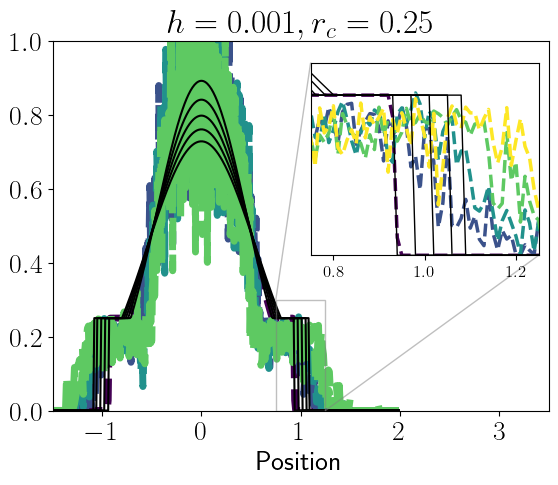

In [55]:
x0, m_vals = initial_data(rho_0, 1.5, h)
part_sol, runtime = solve_ODE(x0, m_vals, alg, ratio, num_batches, moll_eps, f_double_prime_epsilon, grad_V, t_step, t_max)

plot_inset(part_sol, m_vals)

def func(x):
    return exact(t_max, x)
error = wass_2_approx(part_sol[-1], m_vals, func, 1.5, .005)
print("Error = " + str(error) + ".")